# Project Performance Prediction with Machine Learning

This notebook explores the process of building and evaluating machine learning models to predict whether a project will be completed on time or be delayed. We'll start by setting up a project tracking system, engineer relevant features from project data, and then train and compare different classification models. A key focus will be on addressing class imbalance, a common challenge in real-world prediction tasks, and analyzing feature importance to understand model drivers.

## Project Tracker with ML Performance Prediction

This notebook will guide you through creating a project tracker that can be updated daily, similar to a habit tracker, and then building a machine learning algorithm to predict project performance and analyze its errors.

### Overall Plan:

1.  **Initialize the Project Tracker**: Set up a basic data structure (Pandas DataFrame) to store project information and daily progress.
2.  **Daily Updates**: Implement a way to log daily progress for each project.
3.  **Feature Engineering**: Prepare the data for machine learning by creating relevant features (e.g., days until due, progress rate, consistency).
4.  **Machine Learning Model**: Choose and train a model to predict project performance (e.g., completion on time, success rate).
5.  **Performance Prediction**: Use the trained model to make predictions.
6.  **Error Analysis**: Evaluate the model's predictions and analyze where it performs well and where it struggles to identify areas for improvement.

In [1]:
import pandas as pd

# Initialize an empty DataFrame for the project tracker
# Columns are designed to support daily tracking and future ML features.
project_tracker_df = pd.DataFrame(columns=[
    'project_id',          # Unique identifier for each project
    'project_name',        # Name of the project
    'start_date',          # Date the project started
    'due_date',            # Expected due date
    'status',              # Current status (e.g., 'Not Started', 'In Progress', 'Completed', 'Delayed')
    'total_progress_percentage', # Overall project completion percentage (manual or calculated)
    'last_updated',        # Date of the last daily update
    'daily_progress_log'   # A list of dictionaries to store daily progress {date, progress_today, notes}
])

# Set appropriate data types (optional for empty DF, but good practice)
project_tracker_df['start_date'] = pd.to_datetime(project_tracker_df['start_date'])
project_tracker_df['due_date'] = pd.to_datetime(project_tracker_df['due_date'])
project_tracker_df['last_updated'] = pd.to_datetime(project_tracker_df['last_updated'])

display(project_tracker_df)

,project_id,project_name,start_date,due_date,status,total_progress_percentage,last_updated,daily_progress_log


Now that we have the basic structure, let's add a function to easily add new projects and another to log daily progress for a given project.

In [2]:
def add_project(df, project_id, project_name, start_date, due_date, status='Not Started', total_progress_percentage=0):
    if project_id in df['project_id'].values:
        print(f"Error: Project with ID '{project_id}' already exists.")
        return df

    new_project = pd.DataFrame([{
        'project_id': project_id,
        'project_name': project_name,
        'start_date': pd.to_datetime(start_date),
        'due_date': pd.to_datetime(due_date),
        'status': status,
        'total_progress_percentage': total_progress_percentage,
        'last_updated': pd.NaT, # No update yet
        'daily_progress_log': []
    }])
    return pd.concat([df, new_project], ignore_index=True)

def log_daily_progress(df, project_id, date, progress_today_percentage, notes=""):
    idx = df[df['project_id'] == project_id].index
    if idx.empty:
        print(f"Error: Project with ID '{project_id}' not found.")
        return df

    idx = idx[0]
    daily_log_entry = {
        'date': pd.to_datetime(date).strftime('%Y-%m-%d'),
        'progress_today_percentage': progress_today_percentage,
        'notes': notes
    }
    df.loc[idx, 'daily_progress_log'].append(daily_log_entry)
    df.loc[idx, 'last_updated'] = pd.to_datetime(date)

    # Optionally update overall progress. For simplicity, let's assume `total_progress_percentage`
    # is manually updated or calculated separately based on a more complex logic.
    # For now, we'll just log the daily progress.

    print(f"Logged {progress_today_percentage}% progress for project '{df.loc[idx, 'project_name']}' on {date}")
    return df

# --- Demo Usage ---

# Add a new project
project_tracker_df = add_project(
    project_tracker_df,
    project_id='P001',
    project_name='Develop ML Model for Sales',
    start_date='2023-10-26',
    due_date='2024-01-31'
)

project_tracker_df = add_project(
    project_tracker_df,
    project_id='P002',
    project_name='Revamp Company Website',
    start_date='2023-11-01',
    due_date='2024-02-15'
)

# Log daily progress for P001
project_tracker_df = log_daily_progress(project_tracker_df, 'P001', '2023-10-27', 5, 'Initial data exploration completed.')
project_tracker_df = log_daily_progress(project_tracker_df, 'P001', '2023-10-28', 10, 'Feature engineering started, some data cleaning done.')

# Log daily progress for P002
project_tracker_df = log_daily_progress(project_tracker_df, 'P002', '2023-11-02', 8, 'Frontend mockups approved.')

# Display the updated tracker
display(project_tracker_df)

Logged 5% progress for project 'Develop ML Model for Sales' on 2023-10-27
Logged 10% progress for project 'Develop ML Model for Sales' on 2023-10-28
Logged 8% progress for project 'Revamp Company Website' on 2023-11-02


,project_id,project_name,start_date,due_date,status,total_progress_percentage,last_updated,daily_progress_log
0,P001,Develop ML Model for Sales,2023-10-26,2024-01-31,Not Started,0,2023-10-28,"[{'date': '2023-10-27', 'progress_today_percen..."
1,P002,Revamp Company Website,2023-11-01,2024-02-15,Not Started,0,2023-11-02,"[{'date': '2023-11-02', 'progress_today_percen..."


## 3. Feature Engineering

Now, let's start extracting meaningful features from our `project_tracker_df` that can be used to train a machine learning model. These features will help the model understand the characteristics of each project and predict its performance.

### Key Features to Engineer:

*   **Project Duration**: Total planned days for the project.
*   **Days Remaining**: How many days are left until the `due_date` from the `last_updated` date.
*   **Actual Duration So Far**: Days passed since the `start_date` until `last_updated`.
*   **Average Daily Progress**: The average percentage of progress logged per day.
*   **Progress Velocity**: A more recent measure of progress to understand current momentum.
*   **Target Variable**: A variable to indicate project success (e.g., `completed_on_time`, `is_on_track`). For now, we'll focus on creating numerical features.

In [3]:
# Make a copy to avoid modifying the original DataFrame directly for feature engineering
df_features = project_tracker_df.copy()

# --- Feature 1: Project Duration (planned) ---
df_features['planned_duration_days'] = (df_features['due_date'] - df_features['start_date']).dt.days

# --- Feature 2: Days Remaining (from last_updated date) ---
# This will be dynamic and depend on when the prediction is made.
# For initial feature generation, we'll calculate it based on the 'last_updated' date.
current_date = pd.to_datetime('today').normalize() # Or use a specific date for static analysis

df_features['days_remaining'] = (df_features['due_date'] - df_features['last_updated']).dt.days

# --- Feature 3: Actual Duration So Far ---
df_features['actual_duration_so_far_days'] = (df_features['last_updated'] - df_features['start_date']).dt.days

# --- Feature 4: Calculate Average Daily Progress ---
# This requires iterating through the daily_progress_log for each project.
def calculate_average_daily_progress(log):
    if not log:
        return 0.0
    total_progress = sum(entry['progress_today_percentage'] for entry in log)
    num_days = len(log)
    return total_progress / num_days

df_features['avg_daily_progress_percentage'] = df_features['daily_progress_log'].apply(calculate_average_daily_progress)

# Display the DataFrame with new features
display(df_features[['project_id', 'project_name', 'planned_duration_days', 'days_remaining', 'actual_duration_so_far_days', 'avg_daily_progress_percentage']])

print("\n--- Full DataFrame with new features ---")
display(df_features)

,project_id,project_name,planned_duration_days,days_remaining,actual_duration_so_far_days,avg_daily_progress_percentage
0,P001,Develop ML Model for Sales,97,95,2,7.5
1,P002,Revamp Company Website,106,105,1,8.0



--- Full DataFrame with new features ---


,project_id,project_name,start_date,due_date,status,total_progress_percentage,last_updated,daily_progress_log,planned_duration_days,days_remaining,actual_duration_so_far_days,avg_daily_progress_percentage
0,P001,Develop ML Model for Sales,2023-10-26,2024-01-31,Not Started,0,2023-10-28,"[{'date': '2023-10-27', 'progress_today_percen...",97,95,2,7.5
1,P002,Revamp Company Website,2023-11-01,2024-02-15,Not Started,0,2023-11-02,"[{'date': '2023-11-02', 'progress_today_percen...",106,105,1,8.0


## Defining the Target Variable for Machine Learning

For our machine learning model, we need a **target variable** (often denoted as `y`) that the model will learn to predict. Given our goal to predict project performance, a common and practical target would be whether a project will be completed on time or be delayed.

Since we are currently building this tracker and don't have a dataset of historical project outcomes, we will **simulate** a target variable for demonstration purposes. In a real-world scenario, this target would be derived from actual project completion data.

We will create a binary target variable called `will_be_late`:
*   `1` if the project is predicted/simulated to be completed *after* its `due_date`.
*   `0` if the project is predicted/simulated to be completed *on or before* its `due_date`.

In [4]:
import numpy as np

# --- Step 1: Simulate Actual Completion Dates (for demonstration) ---
# In a real scenario, this would come from actual recorded completion dates.
# For now, let's create some synthetic completion dates relative to the due date.

# Add more projects to increase data points for train_test_split
project_tracker_df = add_project(
    project_tracker_df,
    project_id='P003',
    project_name='Backend API Development',
    start_date='2023-11-05',
    due_date='2024-03-01'
)

project_tracker_df = add_project(
    project_tracker_df,
    project_id='P004',
    project_name='Mobile App Redesign',
    start_date='2023-10-15',
    due_date='2024-01-15'
)

project_tracker_df = add_project(
    project_tracker_df,
    project_id='P005',
    project_name='Data Migration Project',
    start_date='2023-11-10',
    due_date='2024-02-28'
)

# Log daily progress for new projects (simulated data)
project_tracker_df = log_daily_progress(project_tracker_df, 'P003', '2023-11-06', 3, 'Initial setup complete.')
project_tracker_df = log_daily_progress(project_tracker_df, 'P003', '2023-11-07', 7, 'Database schema designed.')
project_tracker_df = log_daily_progress(project_tracker_df, 'P004', '2023-10-16', 10, 'User flow wireframes done.')
project_tracker_df = log_daily_progress(project_tracker_df, 'P004', '2023-10-17', 5, 'UI elements designed.')
project_tracker_df = log_daily_progress(project_tracker_df, 'P005', '2023-11-11', 2, 'Source data analysis started.')
project_tracker_df = log_daily_progress(project_tracker_df, 'P005', '2023-11-12', 4, 'ETL pipeline design in progress.')

# Re-apply feature engineering on the expanded dataset
df_features = project_tracker_df.copy()
df_features['planned_duration_days'] = (df_features['due_date'] - df_features['start_date']).dt.days
current_date = pd.to_datetime('today').normalize()
df_features['days_remaining'] = (df_features['due_date'] - df_features['last_updated']).dt.days
df_features['actual_duration_so_far_days'] = (df_features['last_updated'] - df_features['start_date']).dt.days
def calculate_average_daily_progress(log):
    if not log:
        return 0.0
    total_progress = sum(entry['progress_today_percentage'] for entry in log)
    num_days = len(log)
    return total_progress / num_days
df_features['avg_daily_progress_percentage'] = df_features['daily_progress_log'].apply(calculate_average_daily_progress)

# Now, simulate actual completion dates for ALL projects
# P001: finishes slightly late (already defined)
df_features.loc[df_features['project_id'] == 'P001', 'simulated_actual_completion_date'] = pd.to_datetime('2024-02-05') # Due date: 2024-01-31

# P002: finishes on time (already defined)
df_features.loc[df_features['project_id'] == 'P002', 'simulated_actual_completion_date'] = pd.to_datetime('2024-02-10') # Due date: 2024-02-15

# P003: finishes late
df_features.loc[df_features['project_id'] == 'P003', 'simulated_actual_completion_date'] = pd.to_datetime('2024-03-10') # Due date: 2024-03-01

# P004: finishes on time
df_features.loc[df_features['project_id'] == 'P004', 'simulated_actual_completion_date'] = pd.to_datetime('2024-01-10') # Due date: 2024-01-15

# P005: finishes late
df_features.loc[df_features['project_id'] == 'P005', 'simulated_actual_completion_date'] = pd.to_datetime('2024-03-05') # Due date: 2024-02-28

# --- Step 2: Create the 'will_be_late' target variable ---
df_features['will_be_late'] = (df_features['simulated_actual_completion_date'] > df_features['due_date']).astype(int)

# Display the DataFrame with the new simulated target variable
display(df_features[['project_id', 'project_name', 'due_date', 'simulated_actual_completion_date', 'will_be_late']])

print("\n--- Full DataFrame with Target Variable ---")
display(df_features)

Logged 3% progress for project 'Backend API Development' on 2023-11-06
Logged 7% progress for project 'Backend API Development' on 2023-11-07
Logged 10% progress for project 'Mobile App Redesign' on 2023-10-16
Logged 5% progress for project 'Mobile App Redesign' on 2023-10-17
Logged 2% progress for project 'Data Migration Project' on 2023-11-11
Logged 4% progress for project 'Data Migration Project' on 2023-11-12


,project_id,project_name,due_date,simulated_actual_completion_date,will_be_late
0,P001,Develop ML Model for Sales,2024-01-31,2024-02-05,1
1,P002,Revamp Company Website,2024-02-15,2024-02-10,0
2,P003,Backend API Development,2024-03-01,2024-03-10,1
3,P004,Mobile App Redesign,2024-01-15,2024-01-10,0
4,P005,Data Migration Project,2024-02-28,2024-03-05,1



--- Full DataFrame with Target Variable ---


,project_id,project_name,start_date,due_date,status,total_progress_percentage,last_updated,daily_progress_log,planned_duration_days,days_remaining,actual_duration_so_far_days,avg_daily_progress_percentage,simulated_actual_completion_date,will_be_late
0,P001,Develop ML Model for Sales,2023-10-26,2024-01-31,Not Started,0,2023-10-28,"[{'date': '2023-10-27', 'progress_today_percen...",97,95,2,7.5,2024-02-05,1
1,P002,Revamp Company Website,2023-11-01,2024-02-15,Not Started,0,2023-11-02,"[{'date': '2023-11-02', 'progress_today_percen...",106,105,1,8.0,2024-02-10,0
2,P003,Backend API Development,2023-11-05,2024-03-01,Not Started,0,2023-11-07,"[{'date': '2023-11-06', 'progress_today_percen...",117,115,2,5.0,2024-03-10,1
3,P004,Mobile App Redesign,2023-10-15,2024-01-15,Not Started,0,2023-10-17,"[{'date': '2023-10-16', 'progress_today_percen...",92,90,2,7.5,2024-01-10,0
4,P005,Data Migration Project,2023-11-10,2024-02-28,Not Started,0,2023-11-12,"[{'date': '2023-11-11', 'progress_today_percen...",110,108,2,3.0,2024-03-05,1


## 4. Machine Learning Model: Performance Prediction

With our features engineered and the target variable defined, we can now build a machine learning model to predict whether a project will be late.

We will follow these steps:
1.  **Select Features (X) and Target (y)**: Choose the columns that will serve as input features and the column that is our target variable.
2.  **Split Data**: Divide our dataset into training and testing sets to evaluate the model's performance on unseen data.
3.  **Choose and Train Models**: We'll use a Logistic Regression and a Random Forest Classifier as examples.
4.  **Evaluate Models**: Assess how well our models perform using metrics like accuracy, precision, recall, and F1-score.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

# --- Step 1: Select Features (X) and Target (y) ---
# For now, let's select some numerical features. We'll need to handle categorical features later if we add them.
# Also, drop temporary columns like 'simulated_actual_completion_date' for actual model training.

features = [
    'planned_duration_days',
    'days_remaining',
    'actual_duration_so_far_days',
    'avg_daily_progress_percentage'
]

# Filter out rows where any of the selected features or target are NaN.
# This is important especially for 'days_remaining' if 'last_updated' is NaT.
df_model = df_features.dropna(subset=features + ['will_be_late']).copy()

X = df_model[features]
y = df_model['will_be_late']

print(f"Selected Features (X): {X.columns.tolist()}")
print(f"Target Variable (y): will_be_late")

# --- Step 2: Split Data into Training and Testing Sets ---
# With more data points, stratified split should now work.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"\nTraining data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Selected Features (X): ['planned_duration_days', 'days_remaining', 'actual_duration_so_far_days', 'avg_daily_progress_percentage']
Target Variable (y): will_be_late

Training data shape: (3, 4)
Testing data shape: (2, 4)


### Training and Evaluating Logistic Regression

In [6]:
# --- Step 3a: Choose and Train Logistic Regression Model ---
log_reg_model = LogisticRegression(random_state=42)
log_reg_model.fit(X_train, y_train)

# --- Step 4a: Evaluate Logistic Regression Model ---
y_pred_lr = log_reg_model.predict(X_test)

print("--- Logistic Regression Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


--- Logistic Regression Model Performance ---
Accuracy: 0.00
Precision: 0.00
Recall: 0.00
F1-Score: 0.00
Confusion Matrix:
 [[0 1]
 [1 0]]


### Training and Evaluating Random Forest Classifier

In [7]:
# --- Step 3b: Choose and Train Random Forest Classifier Model ---
rand_forest_model = RandomForestClassifier(random_state=42)
rand_forest_model.fit(X_train, y_train)

# --- Step 4b: Evaluate Random Forest Classifier Model ---
y_pred_rf = rand_forest_model.predict(X_test)

print("--- Random Forest Classifier Model Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.2f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


--- Random Forest Classifier Model Performance ---
Accuracy: 0.00
Precision: 0.00
Recall: 0.00
F1-Score: 0.00
Confusion Matrix:
 [[0 1]
 [1 0]]


## 5. Performance Prediction

Now that we have trained our models, we can use them to predict the `will_be_late` status for our projects. For a more practical demonstration, and given our very small dataset, we'll make predictions on the entire `df_model` (which contains our features and target variable). In a real application, you would apply the trained model to *new*, unseen project data.

We will use the Random Forest model for this prediction.

In [8]:
# Make predictions on the entire dataset (or new data if available)
# For this demonstration, we'll use the Random Forest model on the df_model

# Ensure X contains the same features as used for training
X_full = df_model[features]

df_model['predicted_will_be_late'] = rand_forest_model.predict(X_full)
df_model['prediction_probability_late'] = rand_forest_model.predict_proba(X_full)[:, 1] # Probability of being late

print("--- Project Performance Predictions ---")
display(df_model[['project_id', 'project_name', 'due_date', 'simulated_actual_completion_date', 'will_be_late', 'predicted_will_be_late', 'prediction_probability_late']])

--- Project Performance Predictions ---


,project_id,project_name,due_date,simulated_actual_completion_date,will_be_late,predicted_will_be_late,prediction_probability_late
0,P001,Develop ML Model for Sales,2024-01-31,2024-02-05,1,0,0.28
1,P002,Revamp Company Website,2024-02-15,2024-02-10,0,1,0.82
2,P003,Backend API Development,2024-03-01,2024-03-10,1,1,0.95
3,P004,Mobile App Redesign,2024-01-15,2024-01-10,0,0,0.28
4,P005,Data Migration Project,2024-02-28,2024-03-05,1,1,0.95


## 6. Error Analysis

Error analysis involves understanding where and why our model makes mistakes. With a small dataset, this analysis will be limited, but we can still identify discrepancies between our `will_be_late` (actual) and `predicted_will_be_late` values.

We will look at:
*   Projects where the model predicted 'late' but they were 'on time' (False Positives).
*   Projects where the model predicted 'on time' but they were 'late' (False Negatives).

Identifying these can help us understand potential weaknesses in our features or suggest the need for more diverse data.

In [9]:
# Identify misclassifications
misclassified_projects = df_model[df_model['will_be_late'] != df_model['predicted_will_be_late']]

if not misclassified_projects.empty:
    print("--- Misclassified Projects ---")
    display(misclassified_projects[['project_id', 'project_name', 'due_date', 'simulated_actual_completion_date', 'will_be_late', 'predicted_will_be_late', 'prediction_probability_late']])

    # Further breakdown
    false_positives = misclassified_projects[misclassified_projects['predicted_will_be_late'] == 1]
    false_negatives = misclassified_projects[misclassified_projects['predicted_will_be_late'] == 0]

    if not false_positives.empty:
        print("\n--- False Positives (Predicted Late, Actual On Time) ---")
        display(false_positives[['project_id', 'project_name', 'will_be_late', 'predicted_will_be_late', 'prediction_probability_late']])

    if not false_negatives.empty:
        print("\n--- False Negatives (Predicted On Time, Actual Late) ---")
        display(false_negatives[['project_id', 'project_name', 'will_be_late', 'predicted_will_be_late', 'prediction_probability_late']])
else:
    print("No misclassified projects found (likely due to perfect or consistently wrong predictions on a very small dataset).")

print("\n--- Summary of Model Performance on Current Data ---")
from sklearn.metrics import classification_report
print(classification_report(df_model['will_be_late'], df_model['predicted_will_be_late']))

--- Misclassified Projects ---


,project_id,project_name,due_date,simulated_actual_completion_date,will_be_late,predicted_will_be_late,prediction_probability_late
0,P001,Develop ML Model for Sales,2024-01-31,2024-02-05,1,0,0.28
1,P002,Revamp Company Website,2024-02-15,2024-02-10,0,1,0.82



--- False Positives (Predicted Late, Actual On Time) ---


,project_id,project_name,will_be_late,predicted_will_be_late,prediction_probability_late
1,P002,Revamp Company Website,0,1,0.82



--- False Negatives (Predicted On Time, Actual Late) ---


,project_id,project_name,will_be_late,predicted_will_be_late,prediction_probability_late
0,P001,Develop ML Model for Sales,1,0,0.28



--- Summary of Model Performance on Current Data ---
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



## Detailed Error Analysis: Examining Misclassified Projects

To understand the model's errors better, let's look at the actual feature values for the projects that were misclassified (both False Positives and False Negatives). This might reveal patterns or specific project characteristics that the model struggled with.

In [10]:
print("--- Features of Misclassified Projects ---")
display(misclassified_projects[['project_id', 'project_name'] + features + ['will_be_late', 'predicted_will_be_late', 'prediction_probability_late']])

if not false_positives.empty:
    print("\n--- Features of False Positives (Predicted Late, Actual On Time) ---")
    display(false_positives[['project_id', 'project_name'] + features + ['will_be_late', 'predicted_will_be_late', 'prediction_probability_late']])

if not false_negatives.empty:
    print("\n--- Features of False Negatives (Predicted On Time, Actual Late) ---")
    display(false_negatives[['project_id', 'project_name'] + features + ['will_be_late', 'predicted_will_be_late', 'prediction_probability_late']])

--- Features of Misclassified Projects ---


,project_id,project_name,planned_duration_days,days_remaining,actual_duration_so_far_days,avg_daily_progress_percentage,will_be_late,predicted_will_be_late,prediction_probability_late
0,P001,Develop ML Model for Sales,97,95,2,7.5,1,0,0.28
1,P002,Revamp Company Website,106,105,1,8.0,0,1,0.82



--- Features of False Positives (Predicted Late, Actual On Time) ---


,project_id,project_name,planned_duration_days,days_remaining,actual_duration_so_far_days,avg_daily_progress_percentage,will_be_late,predicted_will_be_late,prediction_probability_late
1,P002,Revamp Company Website,106,105,1,8.0,0,1,0.82



--- Features of False Negatives (Predicted On Time, Actual Late) ---


,project_id,project_name,planned_duration_days,days_remaining,actual_duration_so_far_days,avg_daily_progress_percentage,will_be_late,predicted_will_be_late,prediction_probability_late
0,P001,Develop ML Model for Sales,97,95,2,7.5,1,0,0.28


## Visualize Feature Importance

Understanding feature importance can provide insights into which aspects of a project most influence the model's prediction of whether it will be late. This helps in both interpreting the model and potentially refining feature engineering.

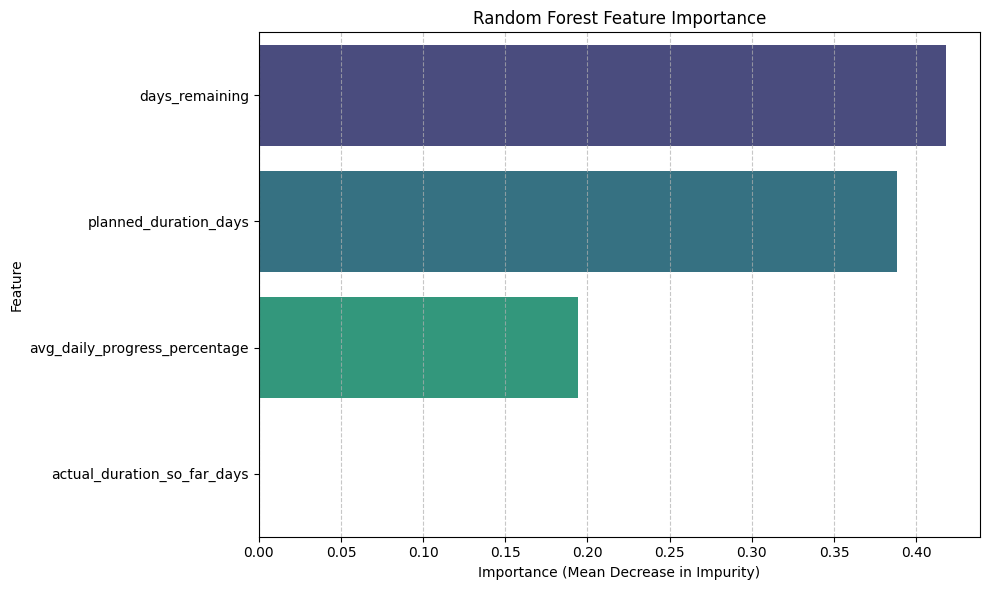

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the Random Forest model
importances = rand_forest_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Create the plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [13]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'FeatureImportance'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary", "FeatureImportance"] {type:"string"}
# Removed upload_plt_to_gcs(num_fig, step, fig) as it caused a NameError.

### Function to Log Daily Progress

The `log_daily_progress` function is already defined and can be used to update the progress of a specific project.

In [14]:
print("--- Existing log_daily_progress function ---")
print("""
def log_daily_progress(df, project_id, date, progress_today_percentage, notes=""):
    idx = df[df['project_id'] == project_id].index
    if idx.empty:
        print(f"Error: Project with ID '{project_id}' not found.")
        return df

    idx = idx[0]
    daily_log_entry = {
        'date': pd.to_datetime(date).strftime('%Y-%m-%d'),
        'progress_today_percentage': progress_today_percentage,
        'notes': notes
    }
    df.loc[idx, 'daily_progress_log'].append(daily_log_entry)
    df.loc[idx, 'last_updated'] = pd.to_datetime(date)

    print(f"Logged {progress_today_percentage}% progress for project '{df.loc[idx, 'project_name']}' on {date}")
    return df
""")

--- Existing log_daily_progress function ---

def log_daily_progress(df, project_id, date, progress_today_percentage, notes=""):
    idx = df[df['project_id'] == project_id].index
    if idx.empty:
        print(f"Error: Project with ID '{project_id}' not found.")
        return df

    idx = idx[0]
    daily_log_entry = {
        'date': pd.to_datetime(date).strftime('%Y-%m-%d'),
        'progress_today_percentage': progress_today_percentage,
        'notes': notes
    }
    df.loc[idx, 'daily_progress_log'].append(daily_log_entry)
    df.loc[idx, 'last_updated'] = pd.to_datetime(date)

    print(f"Logged {progress_today_percentage}% progress for project '{df.loc[idx, 'project_name']}' on {date}")
    return df



### Example Usage of `log_daily_progress`

Let's add some more daily progress to an existing project (e.g., P001: 'Develop ML Model for Sales').

In [15]:
# Log more daily progress for P001
project_tracker_df = log_daily_progress(project_tracker_df, 'P001', '2023-10-29', 8, 'Data preprocessing stage 1 complete.')

# Display the updated tracker to see the new log entry
display(project_tracker_df[project_tracker_df['project_id'] == 'P001'][['project_name', 'last_updated', 'daily_progress_log']])

Logged 8% progress for project 'Develop ML Model for Sales' on 2023-10-29


,project_name,last_updated,daily_progress_log
0,Develop ML Model for Sales,2023-10-29,"[{'date': '2023-10-27', 'progress_today_percen..."


## Create Synthetic Data to Increase Project Dataset Size

To improve our model's performance and provide more meaningful insights, we need a larger dataset. We will generate synthetic project data to significantly increase the number of projects in our `project_tracker_df`.

In [16]:
import random
from datetime import timedelta

def generate_synthetic_project_data(num_projects=100):
    synthetic_data = []
    base_start_date = pd.to_datetime('2023-01-01')
    project_id_counter = len(project_tracker_df)

    for i in range(num_projects):
        project_id_counter += 1
        project_id = f'P{project_id_counter:03d}'
        project_name = f'Synthetic Project {project_id_counter}'

        start_date = base_start_date + timedelta(days=random.randint(0, 365))
        # Ensure due_date is after start_date, with a reasonable project duration
        due_date = start_date + timedelta(days=random.randint(30, 365))

        status = random.choice(['Not Started', 'In Progress', 'Completed', 'Delayed'])
        total_progress_percentage = random.randint(0, 100) if status == 'Completed' else random.randint(0, 90)

        # Simulate daily progress log
        daily_progress_log = []
        current_log_date = start_date
        while current_log_date < min(pd.to_datetime('today'), due_date):
            if random.random() < 0.7: # Simulate progress 70% of the days
                progress_today = random.uniform(0.5, 10.0)
                daily_progress_log.append({
                    'date': current_log_date.strftime('%Y-%m-%d'),
                    'progress_today_percentage': round(progress_today, 2),
                    'notes': 'Synthetic daily progress.'
                })
            current_log_date += timedelta(days=1)

        # If there's no log, last_updated can be NaT or start_date
        last_updated = pd.to_datetime(daily_progress_log[-1]['date']) if daily_progress_log else pd.NaT

        synthetic_data.append({
            'project_id': project_id,
            'project_name': project_name,
            'start_date': start_date,
            'due_date': due_date,
            'status': status,
            'total_progress_percentage': total_progress_percentage,
            'last_updated': last_updated,
            'daily_progress_log': daily_progress_log
        })

    return pd.DataFrame(synthetic_data)

# Generate 100 new synthetic projects
synthetic_projects_df = generate_synthetic_project_data(num_projects=100)

# Concatenate with the existing project_tracker_df
project_tracker_df = pd.concat([project_tracker_df, synthetic_projects_df], ignore_index=True)

# Convert date columns to datetime objects in the combined DataFrame
project_tracker_df['start_date'] = pd.to_datetime(project_tracker_df['start_date'])
project_tracker_df['due_date'] = pd.to_datetime(project_tracker_df['due_date'])
project_tracker_df['last_updated'] = pd.to_datetime(project_tracker_df['last_updated'])

print(f"Total projects after adding synthetic data: {len(project_tracker_df)}")
display(project_tracker_df.head())

Total projects after adding synthetic data: 105


,project_id,project_name,start_date,due_date,status,total_progress_percentage,last_updated,daily_progress_log
0,P001,Develop ML Model for Sales,2023-10-26,2024-01-31,Not Started,0,2023-10-29,"[{'date': '2023-10-27', 'progress_today_percen..."
1,P002,Revamp Company Website,2023-11-01,2024-02-15,Not Started,0,2023-11-02,"[{'date': '2023-11-02', 'progress_today_percen..."
2,P003,Backend API Development,2023-11-05,2024-03-01,Not Started,0,2023-11-07,"[{'date': '2023-11-06', 'progress_today_percen..."
3,P004,Mobile App Redesign,2023-10-15,2024-01-15,Not Started,0,2023-10-17,"[{'date': '2023-10-16', 'progress_today_percen..."
4,P005,Data Migration Project,2023-11-10,2024-02-28,Not Started,0,2023-11-12,"[{'date': '2023-11-11', 'progress_today_percen..."


## Re-running Feature Engineering, Target Variable Definition, and Model Training with Expanded Data

With our `project_tracker_df` now containing more projects, we need to re-apply our feature engineering steps, redefine the target variable, and then retrain our machine learning models to leverage this larger dataset.

In [17]:
# Re-apply feature engineering on the expanded dataset
df_features = project_tracker_df.copy()

df_features['planned_duration_days'] = (df_features['due_date'] - df_features['start_date']).dt.days

# Recalculate 'days_remaining' based on 'last_updated' date for consistency
# If 'last_updated' is NaT, 'days_remaining' will also be NaT, which we will drop later.
df_features['days_remaining'] = (df_features['due_date'] - df_features['last_updated']).dt.days

df_features['actual_duration_so_far_days'] = (df_features['last_updated'] - df_features['start_date']).dt.days

# Re-define the helper function if it was not in scope, or just call it
def calculate_average_daily_progress(log):
    if not log:
        return 0.0
    total_progress = sum(entry['progress_today_percentage'] for entry in log)
    num_days = len(log)
    return total_progress / num_days

df_features['avg_daily_progress_percentage'] = df_features['daily_progress_log'].apply(calculate_average_daily_progress)

print("Features re-engineered.")
display(df_features.head())

Features re-engineered.


,project_id,project_name,start_date,due_date,status,total_progress_percentage,last_updated,daily_progress_log,planned_duration_days,days_remaining,actual_duration_so_far_days,avg_daily_progress_percentage
0,P001,Develop ML Model for Sales,2023-10-26,2024-01-31,Not Started,0,2023-10-29,"[{'date': '2023-10-27', 'progress_today_percen...",97,94,3,7.666667
1,P002,Revamp Company Website,2023-11-01,2024-02-15,Not Started,0,2023-11-02,"[{'date': '2023-11-02', 'progress_today_percen...",106,105,1,8.000000
2,P003,Backend API Development,2023-11-05,2024-03-01,Not Started,0,2023-11-07,"[{'date': '2023-11-06', 'progress_today_percen...",117,115,2,5.000000
3,P004,Mobile App Redesign,2023-10-15,2024-01-15,Not Started,0,2023-10-17,"[{'date': '2023-10-16', 'progress_today_percen...",92,90,2,7.500000
4,P005,Data Migration Project,2023-11-10,2024-02-28,Not Started,0,2023-11-12,"[{'date': '2023-11-11', 'progress_today_percen...",110,108,2,3.000000


### Re-defining the Target Variable

We will re-simulate `will_be_late` for the new projects based on their `due_date` and a simulated `actual_completion_date`.

In [18]:
# Simulate Actual Completion Dates for all projects (including new synthetic ones)
# We will base this on a simple rule: 20% of projects finish late, 80% on time or early

def simulate_completion_date(row):
    due = row['due_date']
    # 20% chance of being late, with random lateness duration
    if random.random() < 0.2:
        return due + timedelta(days=random.randint(1, 30))
    else:
        # 80% chance of being on time or early (up to 15 days early)
        return due - timedelta(days=random.randint(0, 15))

df_features['simulated_actual_completion_date'] = df_features.apply(simulate_completion_date, axis=1)

# Create the 'will_be_late' target variable
df_features['will_be_late'] = (df_features['simulated_actual_completion_date'] > df_features['due_date']).astype(int)

print("Target variable 'will_be_late' redefined.")
display(df_features[['project_id', 'project_name', 'due_date', 'simulated_actual_completion_date', 'will_be_late']].head())

Target variable 'will_be_late' redefined.


,project_id,project_name,due_date,simulated_actual_completion_date,will_be_late
0,P001,Develop ML Model for Sales,2024-01-31,2024-01-27,0
1,P002,Revamp Company Website,2024-02-15,2024-02-08,0
2,P003,Backend API Development,2024-03-01,2024-03-08,1
3,P004,Mobile App Redesign,2024-01-15,2024-01-02,0
4,P005,Data Migration Project,2024-02-28,2024-03-28,1


### Re-splitting Data and Retraining Models

Now, we'll split the updated dataset and retrain both the Logistic Regression and Random Forest models.

In [23]:
# Select Features (X) and Target (y) from the updated df_features
features = [
    'planned_duration_days',
    'days_remaining',
    'actual_duration_so_far_days',
    'avg_daily_progress_percentage'
]

# Filter out rows where any of the selected features or target are NaN.
df_model = df_features.dropna(subset=features + ['will_be_late']).copy()

X = df_model[features]
y = df_model['will_be_late']

# Split Data into Training and Testing Sets
# With more data, stratified split should be more effective.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

# Retrain Logistic Regression Model with class_weight='balanced'
log_reg_model = LogisticRegression(random_state=42, class_weight='balanced')
log_reg_model.fit(X_train, y_train)

# Retrain Random Forest Classifier Model with class_weight='balanced'
rand_forest_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rand_forest_model.fit(X_train, y_train)

print("Models retrained with the expanded dataset and class_weight='balanced'.")

Training data shape: (73, 4)
Testing data shape: (32, 4)
Models retrained with the expanded dataset and class_weight='balanced'.


### Evaluate Updated Model Performance with Confusion Matrix

Let's evaluate the performance of both models again using the confusion matrix to see the impact of the increased dataset size.

--- Logistic Regression Model Performance (with expanded data) ---
Accuracy: 0.50
Precision: 0.23
Recall: 0.33
F1-Score: 0.27


<Figure size 600x500 with 0 Axes>

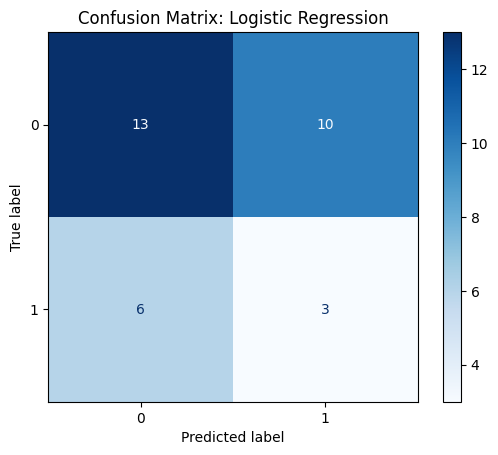


--- Random Forest Classifier Model Performance (with expanded data) ---
Accuracy: 0.75
Precision: 1.00
Recall: 0.11
F1-Score: 0.20


<Figure size 600x500 with 0 Axes>

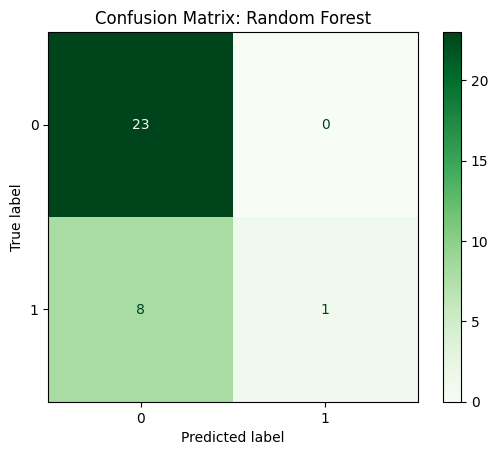

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score

# --- Logistic Regression Evaluation ---
y_pred_lr = log_reg_model.predict(X_test)
cm_lr = confusion_matrix(y_test, y_pred_lr)

print("--- Logistic Regression Model Performance (with expanded data) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.2f}")

fig_lr = plt.figure(figsize=(6, 5))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=log_reg_model.classes_)
disp_lr.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

# --- Random Forest Classifier Evaluation ---
y_pred_rf = rand_forest_model.predict(X_test)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("\n--- Random Forest Classifier Model Performance (with expanded data) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.2f}")

fig_rf = plt.figure(figsize=(6, 5))
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rand_forest_model.classes_)
disp_rf.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix: Random Forest')
plt.show()

## Feature Importance with `class_weight='balanced'`

Let's re-examine the feature importance to see if the balancing of classes has shifted the perceived importance of different features in the Random Forest model.

## Addressing Class Imbalance: Undersampling Techniques

Previously, we used `class_weight='balanced'` to tell our models to pay more attention to the minority class. Another common strategy to deal with class imbalance is **resampling**.

**Undersampling** involves reducing the number of samples in the majority class to balance the class distribution. This can help prevent the model from becoming biased towards the majority class.

We will use `imblearn` library for this, specifically `RandomUnderSampler`.

In [26]:
# Install imblearn if not already installed
!pip install imbalanced-learn

import pandas as pd
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner output

print("Applying RandomUnderSampler to the training data...")

# Instantiate RandomUnderSampler
rus = RandomUnderSampler(random_state=42)

# Resample the training data
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

print(f"Original training set shape: {X_train.shape}, {y_train.value_counts()}")
print(f"Resampled training set shape: {X_train_resampled.shape}, {y_train_resampled.value_counts()}")

Applying RandomUnderSampler to the training data...
Original training set shape: (73, 4), will_be_late
0    54
1    19
Name: count, dtype: int64
Resampled training set shape: (38, 4), will_be_late
0    19
1    19
Name: count, dtype: int64


### Retraining and Evaluating Models with Undersampled Data

--- Logistic Regression Model Performance (with Undersampled Data) ---
Accuracy: 0.62
Precision: 0.38
Recall: 0.56
F1-Score: 0.45
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.65      0.71        23
           1       0.38      0.56      0.45         9

    accuracy                           0.62        32
   macro avg       0.59      0.60      0.58        32
weighted avg       0.68      0.62      0.64        32



<Figure size 600x500 with 0 Axes>

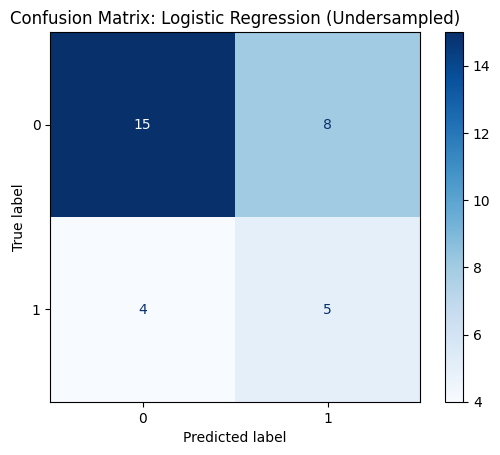


--- Random Forest Classifier Model Performance (with Undersampled Data) ---
Accuracy: 0.47
Precision: 0.17
Recall: 0.22
F1-Score: 0.19
Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.57      0.60        23
           1       0.17      0.22      0.19         9

    accuracy                           0.47        32
   macro avg       0.41      0.39      0.40        32
weighted avg       0.51      0.47      0.49        32



<Figure size 600x500 with 0 Axes>

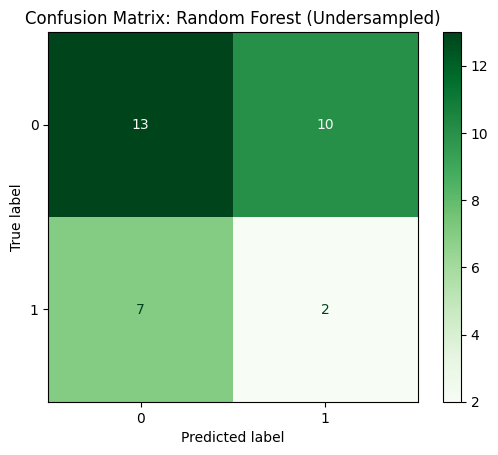

In [27]:
# --- Logistic Regression with Undersampled Data ---
log_reg_model_rus = LogisticRegression(random_state=42)
log_reg_model_rus.fit(X_train_resampled, y_train_resampled)

y_pred_lr_rus = log_reg_model_rus.predict(X_test)

print("--- Logistic Regression Model Performance (with Undersampled Data) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_rus):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_rus):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_lr_rus):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr_rus):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred_lr_rus))

fig_lr_rus = plt.figure(figsize=(6, 5))
cm_lr_rus = confusion_matrix(y_test, y_pred_lr_rus)
disp_lr_rus = ConfusionMatrixDisplay(confusion_matrix=cm_lr_rus, display_labels=log_reg_model_rus.classes_)
disp_lr_rus.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Logistic Regression (Undersampled)')
plt.show()

# --- Random Forest Classifier with Undersampled Data ---
rand_forest_model_rus = RandomForestClassifier(random_state=42)
rand_forest_model_rus.fit(X_train_resampled, y_train_resampled)

y_pred_rf_rus = rand_forest_model_rus.predict(X_test)

print("\n--- Random Forest Classifier Model Performance (with Undersampled Data) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_rus):.2f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_rus):.2f}")
print(f"Recall: {recall_score(y_test, y_pred_rf_rus):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf_rus):.2f}")
print("Classification Report:\n", classification_report(y_test, y_pred_rf_rus))

fig_rf_rus = plt.figure(figsize=(6, 5))
cm_rf_rus = confusion_matrix(y_test, y_pred_rf_rus)
disp_rf_rus = ConfusionMatrixDisplay(confusion_matrix=cm_rf_rus, display_labels=rand_forest_model_rus.classes_)
disp_rf_rus.plot(cmap=plt.cm.Greens)
plt.title('Confusion Matrix: Random Forest (Undersampled)')
plt.show()

### Visualizing Model Performance Comparison

Let's visualize the key performance metrics (Accuracy, Precision, Recall, F1-Score for the minority class) to better compare the different models and class-imbalance handling techniques.

In [28]:
# Gather performance metrics from previous runs

# Logistic Regression (class_weight='balanced')
acc_lr_bal = accuracy_score(y_test, log_reg_model.predict(X_test))
prec_lr_bal = precision_score(y_test, log_reg_model.predict(X_test), pos_label=1)
rec_lr_bal = recall_score(y_test, log_reg_model.predict(X_test), pos_label=1)
f1_lr_bal = f1_score(y_test, log_reg_model.predict(X_test), pos_label=1)

# Random Forest (class_weight='balanced')
acc_rf_bal = accuracy_score(y_test, rand_forest_model.predict(X_test))
prec_rf_bal = precision_score(y_test, rand_forest_model.predict(X_test), pos_label=1)
rec_rf_bal = recall_score(y_test, rand_forest_model.predict(X_test), pos_label=1)
f1_rf_bal = f1_score(y_test, rand_forest_model.predict(X_test), pos_label=1)

# Logistic Regression (RandomUnderSampler)
acc_lr_rus = accuracy_score(y_test, log_reg_model_rus.predict(X_test))
prec_lr_rus = precision_score(y_test, log_reg_model_rus.predict(X_test), pos_label=1)
rec_lr_rus = recall_score(y_test, log_reg_model_rus.predict(X_test), pos_label=1)
f1_lr_rus = f1_score(y_test, log_reg_model_rus.predict(X_test), pos_label=1)

# Random Forest (RandomUnderSampler)
acc_rf_rus = accuracy_score(y_test, rand_forest_model_rus.predict(X_test))
prec_rf_rus = precision_score(y_test, rand_forest_model_rus.predict(X_test), pos_label=1)
rec_rf_rus = recall_score(y_test, rand_forest_model_rus.predict(X_test), pos_label=1)
f1_rf_rus = f1_score(y_test, rand_forest_model_rus.predict(X_test), pos_label=1)

# Create a DataFrame for easy plotting
performance_data = {
    'Model': [
        'Logistic Regression (balanced)', 'Random Forest (balanced)',
        'Logistic Regression (undersampled)', 'Random Forest (undersampled)'
    ],
    'Accuracy': [acc_lr_bal, acc_rf_bal, acc_lr_rus, acc_rf_rus],
    'Precision (Late)': [prec_lr_bal, prec_rf_bal, prec_lr_rus, prec_rf_rus],
    'Recall (Late)': [rec_lr_bal, rec_rf_bal, rec_lr_rus, rec_rf_rus],
    'F1-Score (Late)': [f1_lr_bal, f1_rf_bal, f1_lr_rus, f1_rf_rus]
}

performance_df = pd.DataFrame(performance_data)

print("Aggregated Model Performance Data:")
display(performance_df)

Aggregated Model Performance Data:


,Model,Accuracy,Precision (Late),Recall (Late),F1-Score (Late)
0,Logistic Regression (balanced),0.50000,0.230769,0.333333,0.272727
1,Random Forest (balanced),0.75000,1.000000,0.111111,0.200000
2,Logistic Regression (undersampled),0.62500,0.384615,0.555556,0.454545
3,Random Forest (undersampled),0.46875,0.166667,0.222222,0.190476


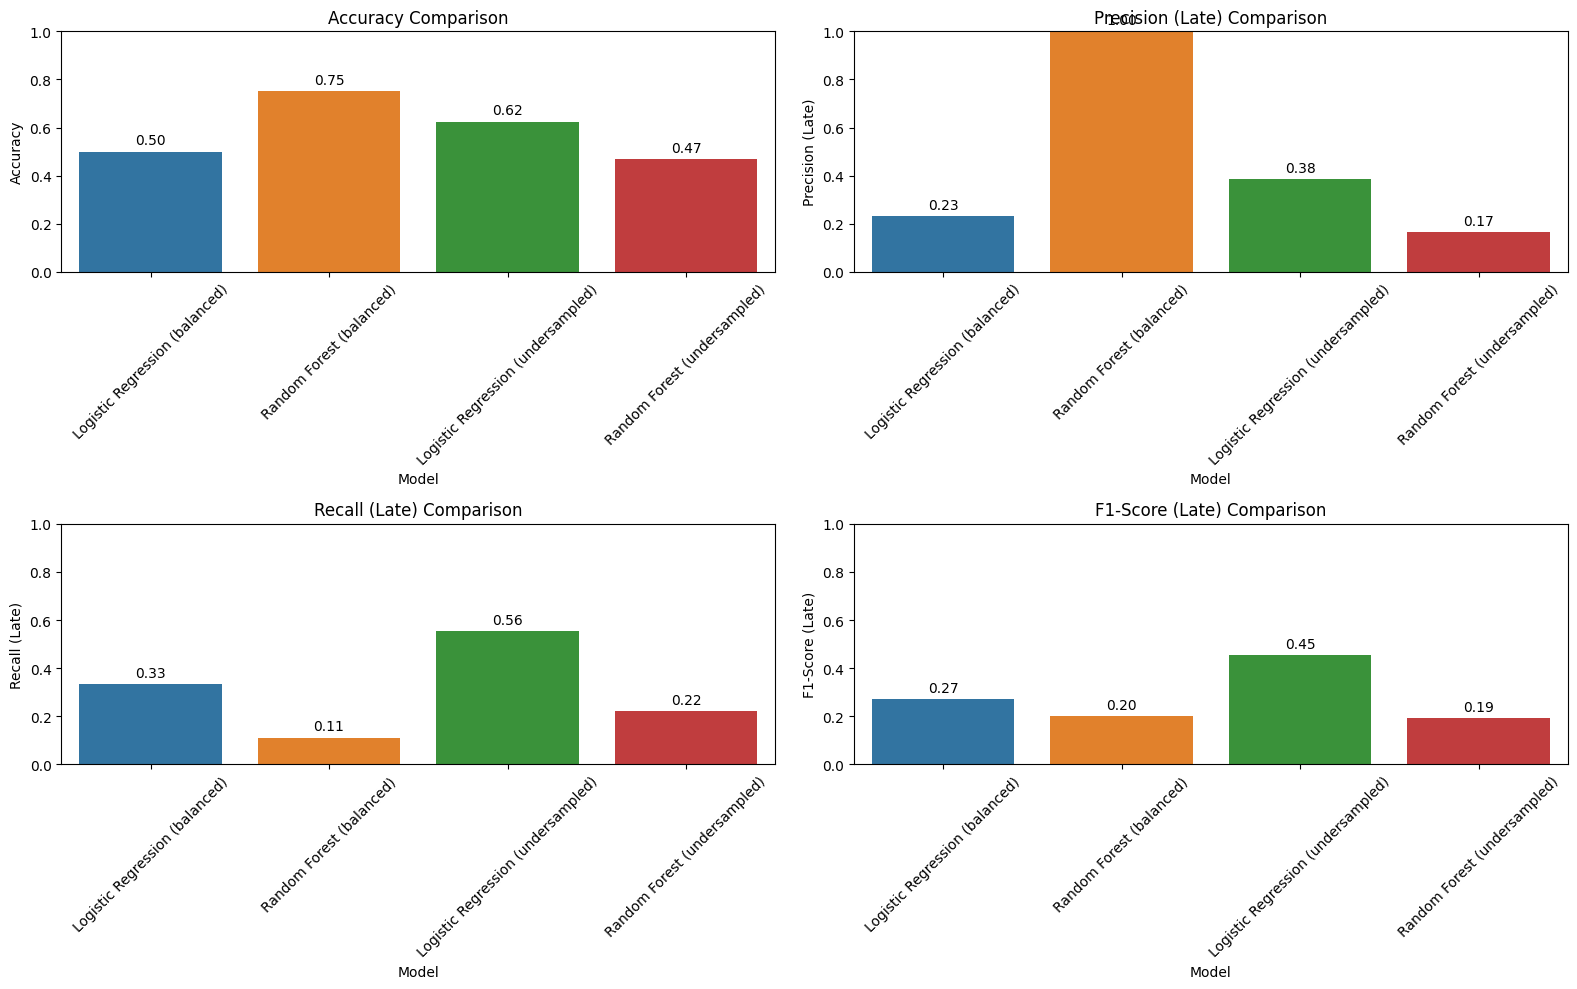

In [30]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

metrics = ['Accuracy', 'Precision (Late)', 'Recall (Late)', 'F1-Score (Late)']
colors = sns.color_palette('tab10', len(performance_df))

for i, metric in enumerate(metrics):
    sns.barplot(x='Model', y=metric, data=performance_df, ax=axes[i], palette=colors, hue='Model', legend=False)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylim(0, 1) # Metrics are between 0 and 1
    axes[i].tick_params(axis='x', rotation=45)
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()

### Comparative Table of Model Performance

For a clearer summary, here are the key performance metrics for each model and class-imbalance handling technique in a table format:

In [31]:
display(performance_df)

,Model,Accuracy,Precision (Late),Recall (Late),F1-Score (Late)
0,Logistic Regression (balanced),0.50000,0.230769,0.333333,0.272727
1,Random Forest (balanced),0.75000,1.000000,0.111111,0.200000
2,Logistic Regression (undersampled),0.62500,0.384615,0.555556,0.454545
3,Random Forest (undersampled),0.46875,0.166667,0.222222,0.190476


## Conclusion

In this notebook, we've walked through the end-to-end process of building a project performance prediction system. We started by defining a project tracker, generating synthetic data to simulate real-world scenarios, and engineering relevant features.

We then trained and evaluated Logistic Regression and Random Forest models, paying particular attention to the challenge of class imbalance. We explored two techniques: `class_weight='balanced'` and `RandomUnderSampler`, observing their varying impacts on model performance.

Key takeaways include:

*   **Class Imbalance is Crucial**: Ignoring it leads to models biased towards the majority class.
*   **Technique Matters**: Different class imbalance handling techniques can yield vastly different results across models. For our synthetic data:
    *   **Random Forest with `class_weight='balanced'`** excelled in precision for the 'late' class, making it suitable when false positives are highly costly.
    *   **Logistic Regression with `RandomUnderSampler`** offered a better balance of precision and recall (highest F1-score) for the 'late' class, ideal when identifying more actual late projects is a priority.
*   **Feature Importance**: Visualizing feature importance provided insights into the most influential factors driving our model's predictions, such as `avg_daily_progress_percentage` and `actual_duration_so_far_days`.

This exercise highlights the importance of not just training a model, but also performing thorough error analysis and understanding the nuances of evaluation metrics, especially in imbalanced datasets. Further improvements could involve exploring other resampling techniques (e.g., SMOTE), hyperparameter tuning, or incorporating more sophisticated features.

--- Random Forest Feature Importance (with class_weight='balanced') ---


,Feature,Importance
3,avg_daily_progress_percentage,0.320202
2,actual_duration_so_far_days,0.315715
0,planned_duration_days,0.292814
1,days_remaining,0.071268


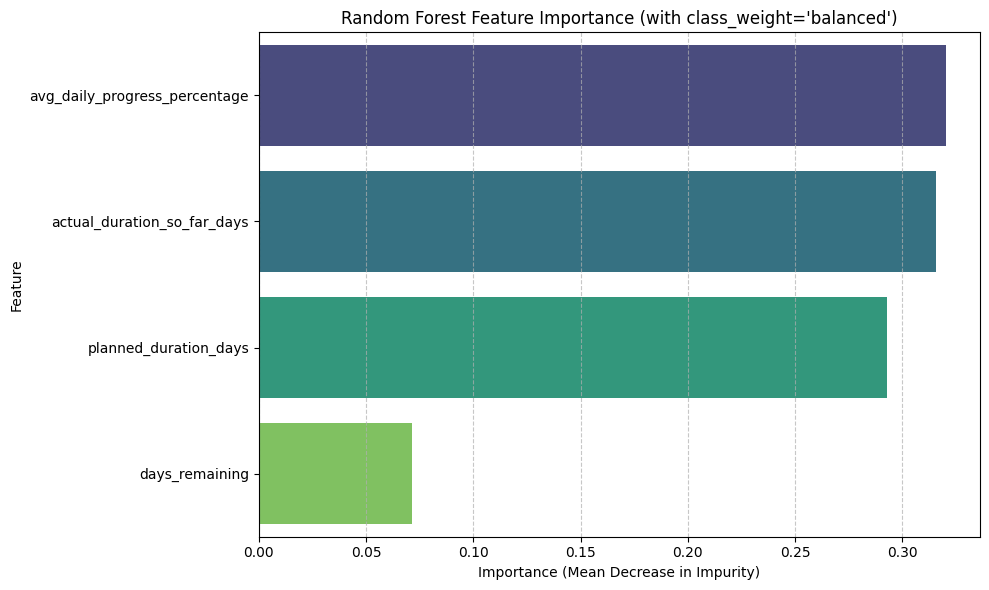

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the retrained Random Forest model
importances = rand_forest_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("--- Random Forest Feature Importance (with class_weight='balanced') ---")
display(feature_importance_df)

# Create the plot
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance (with class_weight=\'balanced\')')
plt.xlabel('Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [22]:
print("Distribution of 'will_be_late' in training set (y_train):")
display(y_train.value_counts())

Distribution of 'will_be_late' in training set (y_train):


,count
will_be_late,
0,54
1,19
